# Lesson 4 : Image Histogram & Intensity Distribution

This lesson is where image enhancement and segmentation truly begin.

Understanding histograms = understanding brightness structure.

### What Is an Image Histogram?

An image histogram shows:

> How many pixels exist at each intensity level.

For grayscale image:

* X-axis → intensity (0–255 or 0–1)
* Y-axis → number of pixels

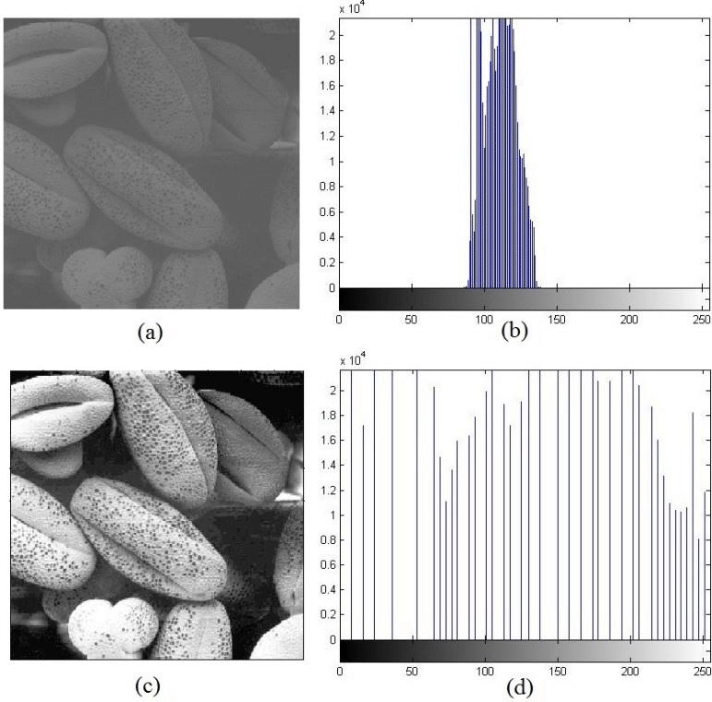
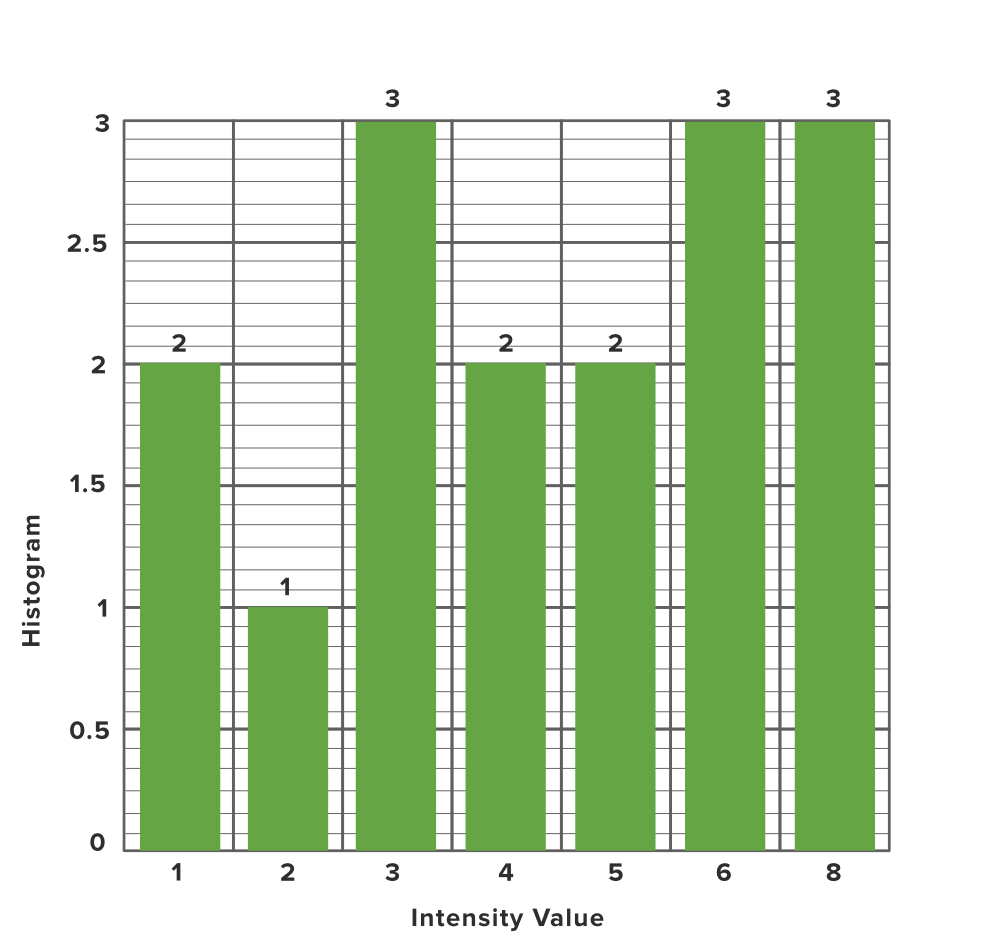

### Why Histogram Is Important

Histogram tells you:

* Is image dark?
* Is image bright?
* Is image low contrast?
* Is image high contrast?
* Are there intensity peaks?
* Is thresholding possible?

### Compute Histogram in skimage

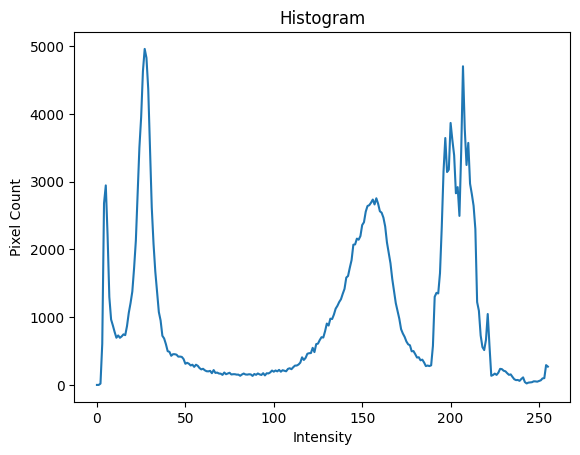

In [1]:
from skimage import data, exposure
import matplotlib.pyplot as plt

img = data.camera()

hist, bins = exposure.histogram(img)

plt.plot(bins, hist)
plt.title("Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.show()

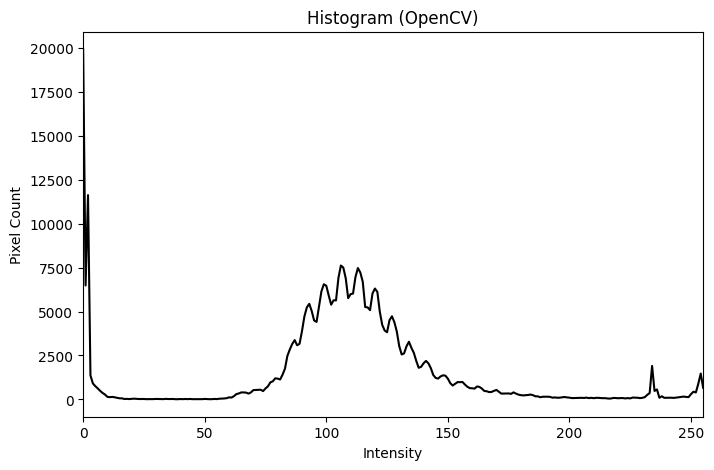

In [23]:
import cv2
import matplotlib.pyplot as plt

# Load sample image (grayscale)
img = cv2.imread("fundus2.jpg", cv2.IMREAD_GRAYSCALE)

# Compute histogram
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

# Plot histogram
plt.figure(figsize=(8,5))
plt.plot(hist, color='black')
plt.title("Histogram (OpenCV)")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.xlim([0, 255])
plt.show()

cv2.calcHist(images, channels, mask, histSize, ranges)
- images → list of images [img]
- channels → [0] for grayscale (use [0,1,2] for RGB)
- mask → None (whole image)
- histSize → [256] (number of bins)
- ranges → [0,256] (intensity range)
- plt.plot(hist) → line plot of pixel counts
- plt.xlim([0,255]) → limit x-axis to intensity range

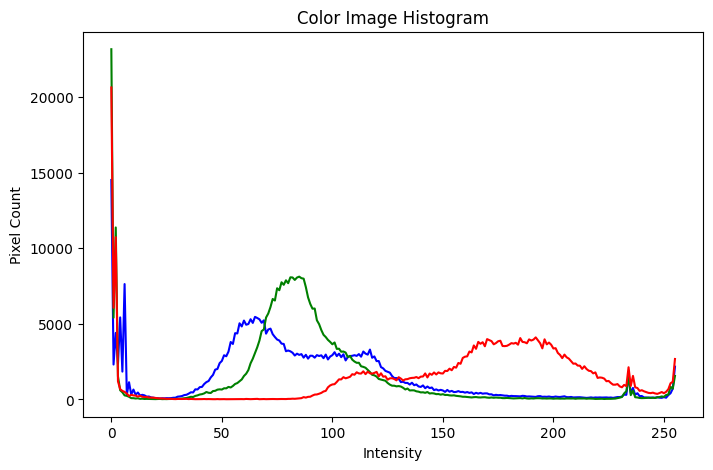

In [24]:
img_color = cv2.imread("fundus2.jpg")
colors = ('b','g','r')

plt.figure(figsize=(8,5))
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_color], [i], None, [256], [0,256])
    plt.plot(hist, color=col)
plt.title("Color Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.show()

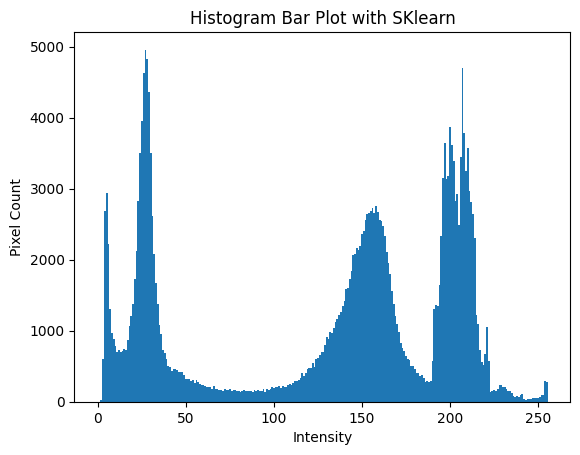

In [25]:
from skimage import data, exposure
import matplotlib.pyplot as plt

img = data.camera()

hist, bins = exposure.histogram(img)

plt.bar(bins, hist, width=1)
plt.title("Histogram Bar Plot with SKlearn")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.show()

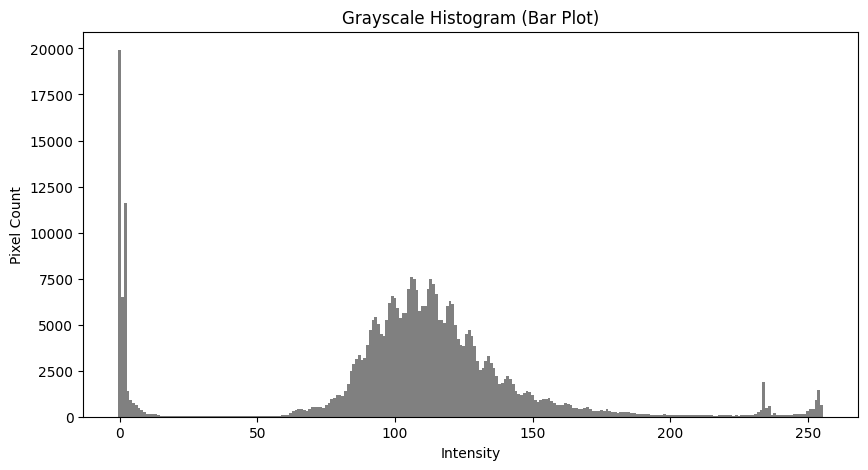

In [27]:
img = cv2.imread("fundus2.jpg", cv2.IMREAD_GRAYSCALE)

# Compute histogram
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

# Create bins for bar plot
bins = np.arange(256)

# Plot histogram as bar plot
plt.figure(figsize=(10,5))
plt.bar(bins, hist[:,0], width=1, color='gray')
plt.title("Grayscale Histogram (Bar Plot)")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.show()

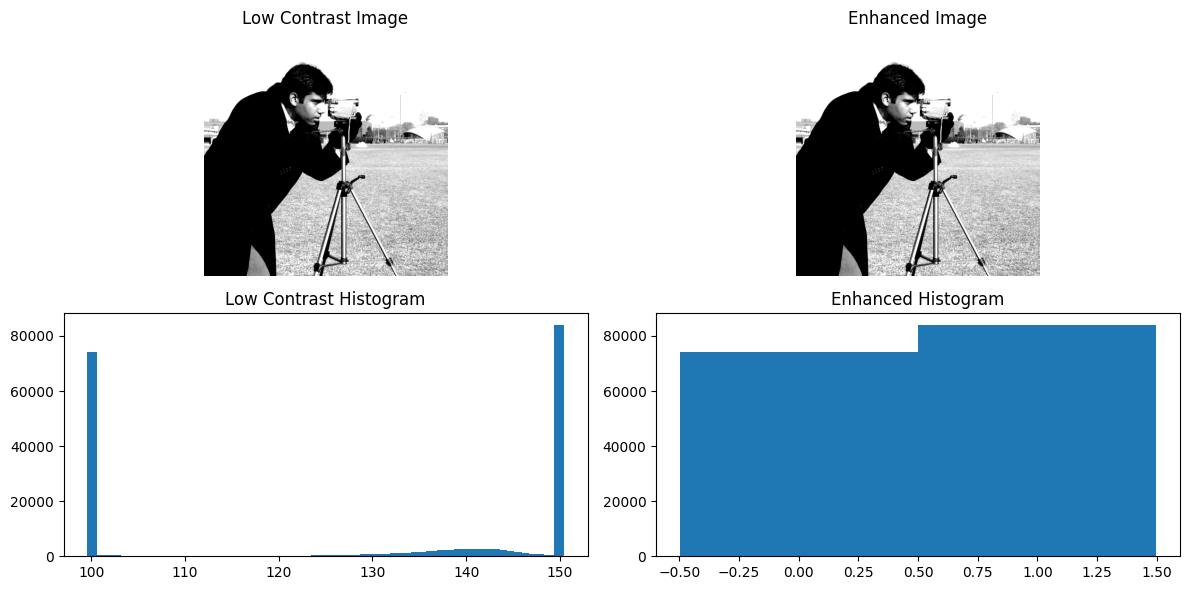

In [8]:
img = data.camera()

# Convert to low contrast (compress intensity range)
low_contrast = exposure.rescale_intensity(img, in_range=(50, 180), out_range=(100, 150))

# Enhance the low contrast image
# Contrast Stretching
# After rescaling, histogram spreads across full range.
enhanced = exposure.rescale_intensity(low_contrast)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low Contrast Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced Image")
plt.axis("off")

plt.subplot(2, 2, 3)
hist_low, bins_low = exposure.histogram(low_contrast)
plt.bar(bins_low, hist_low, width=1)
plt.title("Low Contrast Histogram")

plt.subplot(2, 2, 4)
hist_enh, bins_enh = exposure.histogram(enhanced)
plt.bar(bins_enh, hist_enh, width=1)
plt.title("Enhanced Histogram")

plt.tight_layout()
plt.show()

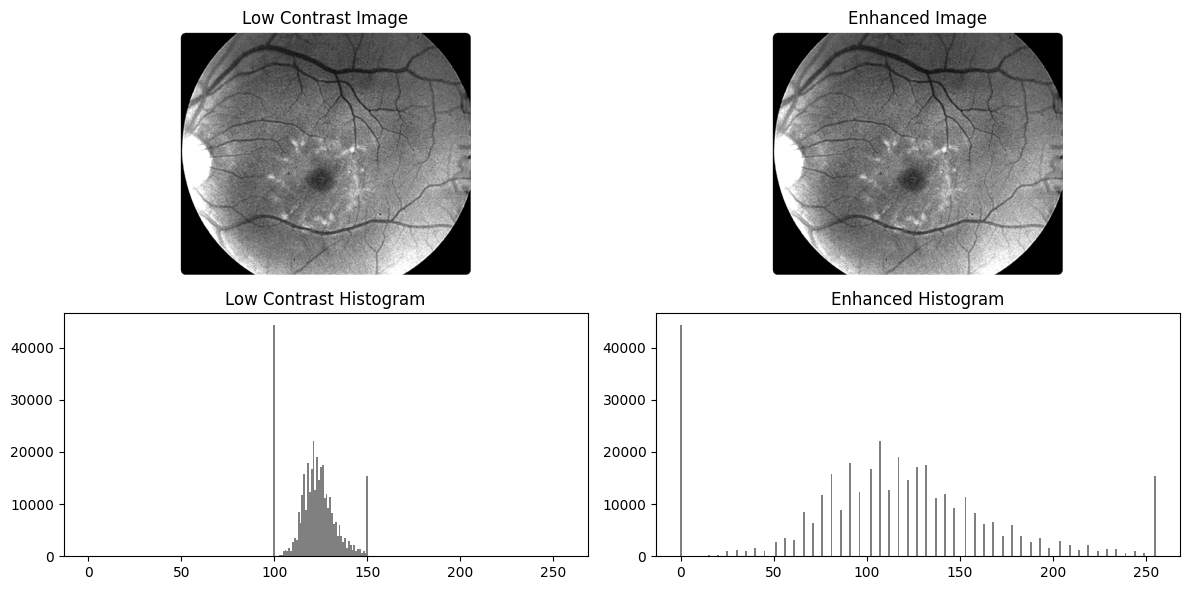

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("fundus2.jpg", cv2.IMREAD_GRAYSCALE)

# Compress intensity from 50-180 -> 100-150
low_contrast = np.clip(img, 50, 180)  # clip values outside 50-180
low_contrast = ((low_contrast - 50) / (180 - 50) * (150 - 100) + 100).astype(np.uint8)

min_val = low_contrast.min()
max_val = low_contrast.max()
enhanced = ((low_contrast - min_val) / (max_val - min_val) * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

# Low Contrast Image
plt.subplot(2, 2, 1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low Contrast Image")
plt.axis("off")

# Enhanced Image
plt.subplot(2, 2, 2)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced Image")
plt.axis("off")

# Histogram of Low Contrast Image
plt.subplot(2, 2, 3)
hist_low = cv2.calcHist([low_contrast], [0], None, [256], [0, 256])
plt.bar(np.arange(256), hist_low[:,0], width=1, color='gray')
plt.title("Low Contrast Histogram")

# Histogram of Enhanced Image
plt.subplot(2, 2, 4)
hist_enh = cv2.calcHist([enhanced], [0], None, [256], [0, 256])
plt.bar(np.arange(256), hist_enh[:,0], width=1, color='gray')
plt.title("Enhanced Histogram")

plt.tight_layout()
plt.show()

### Understanding Histogram Shape

- Narrow Histogram → Low Contrast (Pixels are concentrated in small range)
- Wide Histogram → High Contrast (Pixels spread across full range)
- Shifted Left → Dark Image
- Shifted Right → Bright Image

### Histogram Equalization
Contrast stretching is linear.
Histogram Equalization is nonlinear.
It redistributes intensities to:
> Make histogram more uniform.

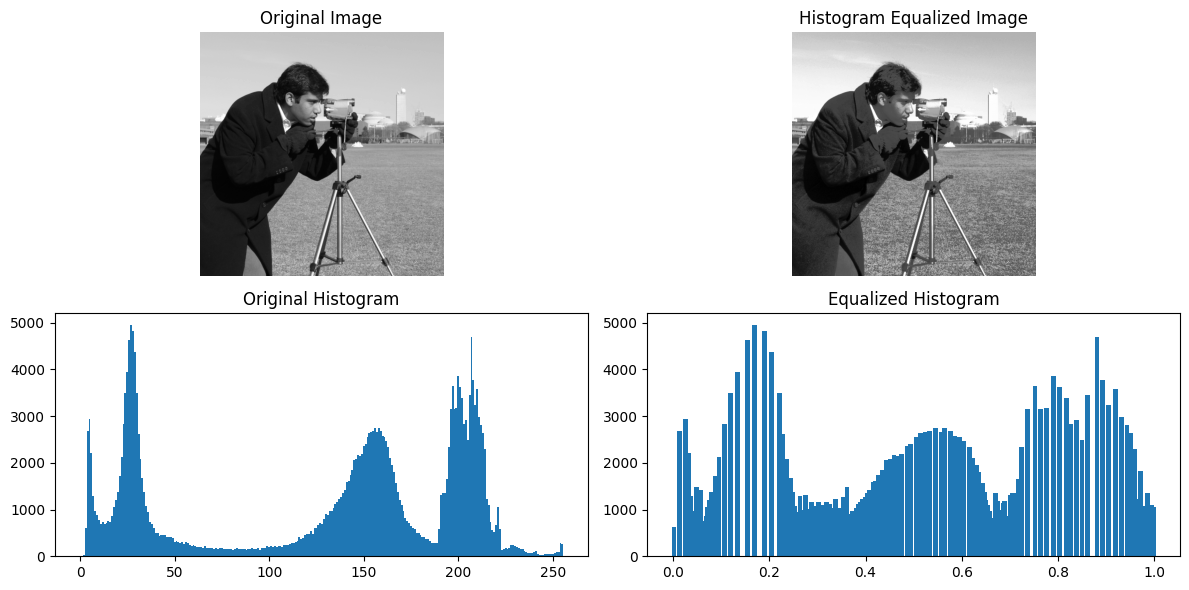

In [10]:
# Load normal image
img = data.camera()

# Histogram Equalization
equalized = exposure.equalize_hist(img)

# -------- Plot Images --------
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")

# -------- Plot Histogram of Original --------
plt.subplot(2, 2, 3)
hist_org, bins_org = exposure.histogram(img)
plt.bar(bins_org, hist_org, width=1)
plt.title("Original Histogram")

# -------- Plot Histogram of Equalized --------
plt.subplot(2, 2, 4)
hist_eq, bins_eq = exposure.histogram(equalized)
plt.bar(bins_eq, hist_eq, width=0.01)
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

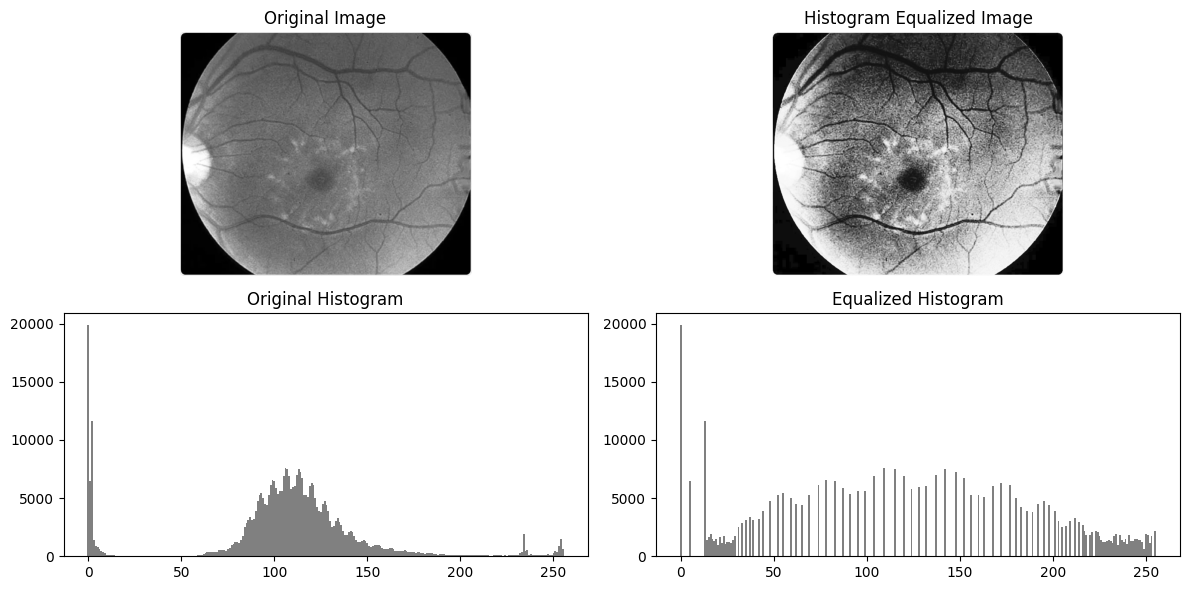

In [30]:
# Load image in grayscale
img = cv2.imread("fundus2.jpg", cv2.IMREAD_GRAYSCALE)  # replace with your image path

# Histogram Equalization
equalized = cv2.equalizeHist(img)

# ---------------------- Plot Images ----------------------
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Equalized Image
plt.subplot(2, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")

# ---------------------- Plot Histograms ----------------------
plt.subplot(2, 2, 3)
hist_org = cv2.calcHist([img], [0], None, [256], [0, 256])
plt.bar(np.arange(256), hist_org[:,0], width=1, color='gray')
plt.title("Original Histogram")

plt.subplot(2, 2, 4)
hist_eq = cv2.calcHist([equalized], [0], None, [256], [0, 256])
plt.bar(np.arange(256), hist_eq[:,0], width=1, color='gray')
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

### **CLAHE (Contrast Limited Adaptive Histogram Equalization)**
CLAHE is an advanced image contrast enhancement technique.
It improves the local contrast of an image while preventing over-amplification of noise.
> CLAHE = Adaptive histogram equalization + Clip limit → Enhances local contrast without amplifying noise.

It is commonly used in:
* Medical imaging (X-rays, MRI)
* Low-light photos
* Satellite and surveillance images

### **How It Works**
1. **Divide the image into small regions (tiles):**
   Instead of equalizing the histogram of the whole image, CLAHE works on small tiles.

2. **Apply histogram equalization locally in each tile:**
   This enhances the contrast in each small region, making details in dark areas more visible.

3. **Limit contrast amplification:**
   A clip limit is applied to prevent extreme amplification of noise in uniform areas.

4. **Merge tiles smoothly:**
   Neighboring tiles are combined using bilinear interpolation to avoid artificial boundaries.

### **Key Features**

* **Adaptive:** Works locally instead of globally
* **Contrast-limited:** Prevents over-brightening or noise amplification
* **Better for low-contrast images:** Reveals hidden details-

### **Equation / Conceptual Idea**

1. Compute histogram in each tile
2. Clip histogram bins above `clip_limit`
3. Redistribute clipped pixels
4. Map pixels according to cumulative distribution function (CDF)

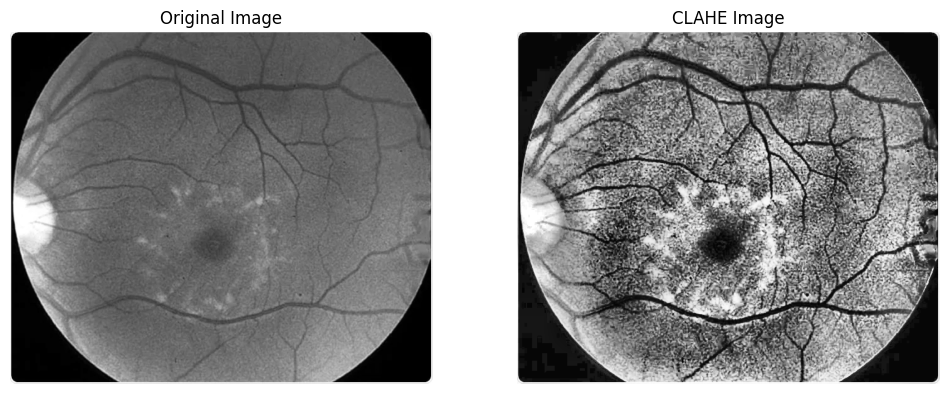

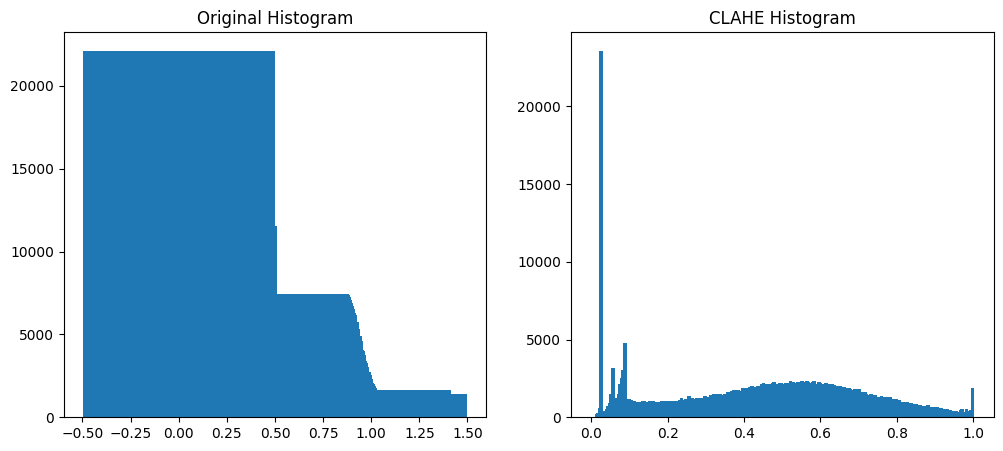

In [20]:
from skimage import io, color

# Load the image
from skimage import io

img = io.imread("fundus2.jpg")

# Convert to grayscale
img = color.rgb2gray(img)

# Apply CLAHE
clahe = exposure.equalize_adapthist(img, clip_limit=0.03)

# -------- Plot Images --------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe, cmap='gray')
plt.title("CLAHE Image")
plt.axis("off")

plt.show()

# -------- Histogram --------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
hist_org, bins_org = exposure.histogram(img)
plt.bar(bins_org, hist_org, width=1)
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
hist_clahe, bins_clahe = exposure.histogram(clahe)
plt.bar(bins_clahe, hist_clahe, width=0.01)
plt.title("CLAHE Histogram")

plt.show()

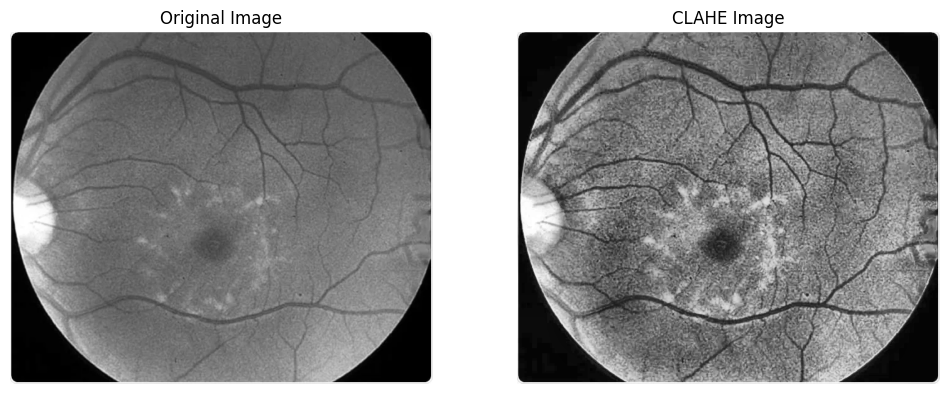

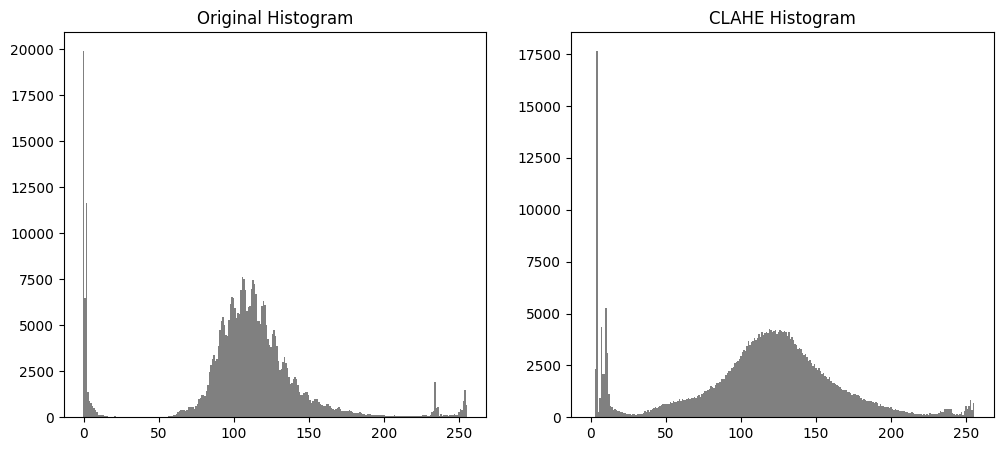

In [36]:
# Load the image
img = cv2.imread("fundus2.jpg")
# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply CLAHE
clahe_obj = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
clahe_img = clahe_obj.apply(img_gray)

# ---------------- Plot Images ----------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE Image")
plt.axis("off")

plt.show()

# ---------------- Plot Histograms ----------------
plt.figure(figsize=(12, 5))

# Original Histogram
plt.subplot(1, 2, 1)
hist_org = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
plt.bar(np.arange(256), hist_org[:,0], width=1, color='gray')
plt.title("Original Histogram")

# CLAHE Histogram
plt.subplot(1, 2, 2)
hist_clahe = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])
plt.bar(np.arange(256), hist_clahe[:,0], width=1, color='gray')
plt.title("CLAHE Histogram")

plt.show()

Otsu Threshold: 60.0


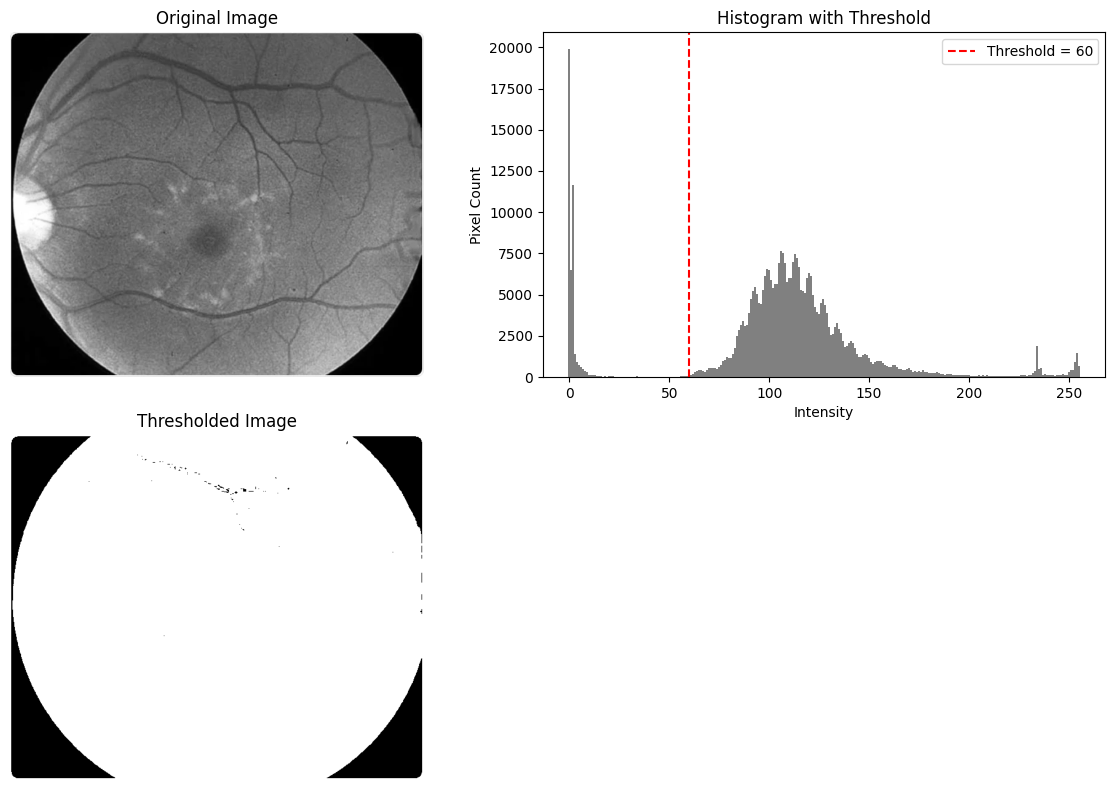

In [33]:
# Load image in grayscale
img = cv2.imread("fundus2.jpg", cv2.IMREAD_GRAYSCALE)

# Compute Otsu's threshold
ret, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu Threshold:", ret)

# Compute histogram
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

# -------- Plot --------
plt.figure(figsize=(12, 8))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Histogram with Otsu Threshold
plt.subplot(2, 2, 2)
plt.bar(np.arange(256), hist[:,0], width=1, color='gray')
plt.axvline(ret, color='r', linestyle='--', label=f'Threshold = {int(ret)}')
plt.title("Histogram with Threshold")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.legend()

# Binary Image
plt.subplot(2, 2, 3)
plt.imshow(binary, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")

plt.tight_layout()
plt.show()